# Banking Customer Churn & Profitability Analytics

## Project Overview

This project analyzes synthetic banking customer data to understand customer churn, profitability, product usage, account activity, and retention opportunities.

The goal is to simulate a real banking analytics project where an analyst helps a financial institution identify customers who may leave, understand which customers are most profitable, and recommend actions to improve retention and business performance.

This project includes:
- Customer profile analysis
- Account balance and product usage analysis
- Revenue and profitability analysis
- Customer churn analysis
- Churn risk scoring
- Basic machine learning model
- SQL analysis
- Excel executive dashboard
- Business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

random.seed(42)
np.random.seed(42)

## 1. Create Synthetic Banking Customer Data

This project uses synthetic data created for portfolio and learning purposes. No real customer, bank, employer, or confidential financial data is used.

The dataset is designed to represent a U.S.-based retail banking environment with customers, account balances, product usage, digital banking activity, revenue, cost, profitability, and churn indicators.

In [2]:
num_customers = 5000

states = [
    "MA", "NY", "CA", "TX", "FL", "WA", "IL", "PA", "GA", "NC",
    "VA", "NJ", "OH", "AZ", "CO", "MI", "MN", "TN", "OR", "MD"
]

age_groups = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
income_bands = ["Under 40K", "40K-75K", "75K-125K", "125K-200K", "200K+"]
customer_segments = ["Mass Market", "Emerging Affluent", "Affluent", "Small Business"]
credit_score_bands = ["Poor", "Fair", "Good", "Very Good", "Excellent"]
tenure_bands = ["0-1 Years", "1-3 Years", "3-5 Years", "5-10 Years", "10+ Years"]

customers = []

for i in range(1, num_customers + 1):
    customer_id = f"CUST{i:06d}"
    
    age_group = random.choices(
        age_groups,
        weights=[0.10, 0.22, 0.24, 0.20, 0.15, 0.09],
        k=1
    )[0]
    
    income_band = random.choices(
        income_bands,
        weights=[0.20, 0.32, 0.27, 0.15, 0.06],
        k=1
    )[0]
    
    segment = random.choices(
        customer_segments,
        weights=[0.58, 0.22, 0.14, 0.06],
        k=1
    )[0]
    
    credit_band = random.choices(
        credit_score_bands,
        weights=[0.08, 0.18, 0.34, 0.25, 0.15],
        k=1
    )[0]
    
    tenure_band = random.choices(
        tenure_bands,
        weights=[0.14, 0.25, 0.20, 0.25, 0.16],
        k=1
    )[0]
    
    customers.append({
        "customer_id": customer_id,
        "state": random.choice(states),
        "age_group": age_group,
        "income_band": income_band,
        "customer_segment": segment,
        "credit_score_band": credit_band,
        "tenure_band": tenure_band
    })

customers_df = pd.DataFrame(customers)

customers_df.head()

,customer_id,state,age_group,income_band,customer_segment,credit_score_band,tenure_band
0,CUST000001,TN,45-54,Under 40K,Mass Market,Fair,5-10 Years
1,CUST000002,MA,18-24,40K-75K,Mass Market,Fair,3-5 Years
2,CUST000003,GA,45-54,75K-125K,Emerging Affluent,Good,3-5 Years
3,CUST000004,FL,55-64,Under 40K,Affluent,Very Good,1-3 Years
4,CUST000005,NJ,25-34,75K-125K,Mass Market,Good,1-3 Years


In [3]:
def income_midpoint(income_band):
    mapping = {
        "Under 40K": 30000,
        "40K-75K": 57500,
        "75K-125K": 100000,
        "125K-200K": 160000,
        "200K+": 240000
    }
    return mapping[income_band]

def tenure_years(tenure_band):
    mapping = {
        "0-1 Years": 0.5,
        "1-3 Years": 2,
        "3-5 Years": 4,
        "5-10 Years": 7,
        "10+ Years": 12
    }
    return mapping[tenure_band]

def credit_score_value(credit_band):
    mapping = {
        "Poor": 560,
        "Fair": 630,
        "Good": 700,
        "Very Good": 760,
        "Excellent": 810
    }
    return mapping[credit_band]

customers_df["estimated_income"] = customers_df["income_band"].apply(income_midpoint)
customers_df["tenure_years"] = customers_df["tenure_band"].apply(tenure_years)
customers_df["estimated_credit_score"] = customers_df["credit_score_band"].apply(credit_score_value)

customers_df.head()

,customer_id,state,age_group,income_band,customer_segment,credit_score_band,tenure_band,estimated_income,tenure_years,estimated_credit_score
0,CUST000001,TN,45-54,Under 40K,Mass Market,Fair,5-10 Years,30000,7.00,630
1,CUST000002,MA,18-24,40K-75K,Mass Market,Fair,3-5 Years,57500,4.00,630
2,CUST000003,GA,45-54,75K-125K,Emerging Affluent,Good,3-5 Years,100000,4.00,700
3,CUST000004,FL,55-64,Under 40K,Affluent,Very Good,1-3 Years,30000,2.00,760
4,CUST000005,NJ,25-34,75K-125K,Mass Market,Good,1-3 Years,100000,2.00,700


In [4]:
account_rows = []

for _, customer in customers_df.iterrows():
    income = customer["estimated_income"]
    tenure = customer["tenure_years"]
    credit_score = customer["estimated_credit_score"]
    segment = customer["customer_segment"]
    
    checking_balance = max(
        0,
        np.random.normal(loc=income * 0.035, scale=income * 0.025)
    )
    
    savings_balance = max(
        0,
        np.random.normal(loc=income * 0.10, scale=income * 0.08)
    )
    
    if segment == "Affluent":
        savings_balance *= 1.8
    elif segment == "Small Business":
        checking_balance *= 2.2
        savings_balance *= 1.3
    elif segment == "Emerging Affluent":
        savings_balance *= 1.35
    
    has_credit_card = random.random() < (0.42 + (credit_score - 600) / 1000)
    has_personal_loan = random.random() < 0.18
    has_mortgage = random.random() < (0.12 if income < 75000 else 0.28)
    has_investment_account = random.random() < (0.08 if segment == "Mass Market" else 0.28)
    has_business_account = segment == "Small Business" and random.random() < 0.75
    
    product_count = sum([
        1,
        checking_balance > 0,
        savings_balance > 500,
        has_credit_card,
        has_personal_loan,
        has_mortgage,
        has_investment_account,
        has_business_account
    ])
    
    digital_logins_90d = np.random.poisson(lam=22)
    branch_visits_90d = np.random.poisson(lam=2)
    support_calls_90d = np.random.poisson(lam=1)
    
    if random.random() < 0.12:
        support_calls_90d += random.randint(3, 8)
    
    monthly_deposits = max(0, np.random.normal(loc=income / 12, scale=income / 30))
    monthly_card_spend = max(0, np.random.normal(loc=income * 0.025, scale=income * 0.018)) if has_credit_card else 0
    
    interest_revenue = (checking_balance * 0.004 + savings_balance * 0.006) / 12
    card_revenue = monthly_card_spend * 0.018
    loan_revenue = 45 if has_personal_loan else 0
    mortgage_revenue = 85 if has_mortgage else 0
    investment_revenue = 55 if has_investment_account else 0
    business_revenue = 75 if has_business_account else 0
    
    monthly_revenue = interest_revenue + card_revenue + loan_revenue + mortgage_revenue + investment_revenue + business_revenue
    
    servicing_cost = 18 + (support_calls_90d * 6) + (branch_visits_90d * 4)
    monthly_profit = monthly_revenue - servicing_cost
    
    churn_probability = 0.08
    
    if tenure < 1:
        churn_probability += 0.10
    if product_count <= 2:
        churn_probability += 0.12
    if support_calls_90d >= 4:
        churn_probability += 0.13
    if digital_logins_90d < 5:
        churn_probability += 0.08
    if monthly_profit < 0:
        churn_probability += 0.06
    if checking_balance + savings_balance < 1000:
        churn_probability += 0.05
    if product_count >= 5:
        churn_probability -= 0.08
    if tenure >= 7:
        churn_probability -= 0.06
    
    churn_probability = min(max(churn_probability, 0.02), 0.75)
    churned = random.random() < churn_probability
    
    if churn_probability >= 0.35:
        churn_risk_band = "High Risk"
    elif churn_probability >= 0.18:
        churn_risk_band = "Medium Risk"
    else:
        churn_risk_band = "Low Risk"
    
    account_rows.append({
        "customer_id": customer["customer_id"],
        "checking_balance": round(checking_balance, 2),
        "savings_balance": round(savings_balance, 2),
        "total_balance": round(checking_balance + savings_balance, 2),
        "has_credit_card": int(has_credit_card),
        "has_personal_loan": int(has_personal_loan),
        "has_mortgage": int(has_mortgage),
        "has_investment_account": int(has_investment_account),
        "has_business_account": int(has_business_account),
        "product_count": product_count,
        "digital_logins_90d": digital_logins_90d,
        "branch_visits_90d": branch_visits_90d,
        "support_calls_90d": support_calls_90d,
        "monthly_deposits": round(monthly_deposits, 2),
        "monthly_card_spend": round(monthly_card_spend, 2),
        "monthly_revenue": round(monthly_revenue, 2),
        "servicing_cost": round(servicing_cost, 2),
        "monthly_profit": round(monthly_profit, 2),
        "churn_probability": round(churn_probability, 3),
        "churn_risk_band": churn_risk_band,
        "churned": int(churned)
    })

accounts_df = pd.DataFrame(account_rows)

banking_df = customers_df.merge(accounts_df, on="customer_id", how="left")

banking_df.head()

,customer_id,state,age_group,income_band,customer_segment,credit_score_band,tenure_band,estimated_income,tenure_years,estimated_credit_score,checking_balance,savings_balance,total_balance,has_credit_card,has_personal_loan,has_mortgage,has_investment_account,has_business_account,product_count,digital_logins_90d,branch_visits_90d,support_calls_90d,monthly_deposits,monthly_card_spend,monthly_revenue,servicing_cost,monthly_profit,churn_probability,churn_risk_band,churned
0,CUST000001,TN,45-54,Under 40K,Mass Market,Fair,5-10 Years,30000,7.00,630,"1,422.54","2,668.17","4,090.70",1,0,1,0,0,5,25,1,7,"2,779.04","1,295.68",110.13,64,46.13,0.07,Low Risk,0
1,CUST000002,MA,18-24,40K-75K,Mass Market,Fair,3-5 Years,57500,4.00,630,"1,177.49","3,334.22","4,511.71",0,0,0,0,0,3,17,2,1,"3,051.29",0.00,2.06,32,-29.94,0.14,Low Risk,0
2,CUST000003,GA,45-54,75K-125K,Emerging Affluent,Good,3-5 Years,100000,4.00,700,0.00,"29,329.01","29,329.01",1,0,0,0,0,3,17,1,1,"7,580.75","1,418.85",40.20,28,12.20,0.08,Low Risk,0
3,CUST000004,FL,55-64,Under 40K,Affluent,Very Good,1-3 Years,30000,2.00,760,831.23,"2,800.63","3,631.86",1,0,0,1,0,5,15,0,6,"4,352.28",66.84,57.88,54,3.88,0.13,Low Risk,0
4,CUST000005,NJ,25-34,75K-125K,Mass Market,Good,1-3 Years,100000,2.00,700,"6,229.98","32,226.50","38,456.48",1,0,0,0,0,4,29,1,0,"12,312.13","2,291.83",59.44,22,37.44,0.08,Low Risk,0


In [5]:
data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

customers_df.to_csv(data_dir / "bank_customer_profiles.csv", index=False)
accounts_df.to_csv(data_dir / "bank_account_activity.csv", index=False)
banking_df.to_csv(data_dir / "banking_churn_profitability_data.csv", index=False)

print("Saved customer profiles:", data_dir / "bank_customer_profiles.csv")
print("Saved account activity:", data_dir / "bank_account_activity.csv")
print("Saved combined banking dataset:", data_dir / "banking_churn_profitability_data.csv")
print("Rows:", len(banking_df))

Saved customer profiles: ..\data\bank_customer_profiles.csv
Saved account activity: ..\data\bank_account_activity.csv
Saved combined banking dataset: ..\data\banking_churn_profitability_data.csv
Rows: 5000


## 2. Load and Review the Banking Dataset

After creating the synthetic datasets, the combined banking dataset is loaded from CSV to simulate a real analyst workflow.

In [6]:
banking = pd.read_csv("../data/banking_churn_profitability_data.csv")

banking.head()

,customer_id,state,age_group,income_band,customer_segment,credit_score_band,tenure_band,estimated_income,tenure_years,estimated_credit_score,checking_balance,savings_balance,total_balance,has_credit_card,has_personal_loan,has_mortgage,has_investment_account,has_business_account,product_count,digital_logins_90d,branch_visits_90d,support_calls_90d,monthly_deposits,monthly_card_spend,monthly_revenue,servicing_cost,monthly_profit,churn_probability,churn_risk_band,churned
0,CUST000001,TN,45-54,Under 40K,Mass Market,Fair,5-10 Years,30000,7.00,630,"1,422.54","2,668.17","4,090.70",1,0,1,0,0,5,25,1,7,"2,779.04","1,295.68",110.13,64,46.13,0.07,Low Risk,0
1,CUST000002,MA,18-24,40K-75K,Mass Market,Fair,3-5 Years,57500,4.00,630,"1,177.49","3,334.22","4,511.71",0,0,0,0,0,3,17,2,1,"3,051.29",0.00,2.06,32,-29.94,0.14,Low Risk,0
2,CUST000003,GA,45-54,75K-125K,Emerging Affluent,Good,3-5 Years,100000,4.00,700,0.00,"29,329.01","29,329.01",1,0,0,0,0,3,17,1,1,"7,580.75","1,418.85",40.20,28,12.20,0.08,Low Risk,0
3,CUST000004,FL,55-64,Under 40K,Affluent,Very Good,1-3 Years,30000,2.00,760,831.23,"2,800.63","3,631.86",1,0,0,1,0,5,15,0,6,"4,352.28",66.84,57.88,54,3.88,0.13,Low Risk,0
4,CUST000005,NJ,25-34,75K-125K,Mass Market,Good,1-3 Years,100000,2.00,700,"6,229.98","32,226.50","38,456.48",1,0,0,0,0,4,29,1,0,"12,312.13","2,291.83",59.44,22,37.44,0.08,Low Risk,0


In [7]:
banking = pd.read_csv("../data/banking_churn_profitability_data.csv")

banking.head()

,customer_id,state,age_group,income_band,customer_segment,credit_score_band,tenure_band,estimated_income,tenure_years,estimated_credit_score,checking_balance,savings_balance,total_balance,has_credit_card,has_personal_loan,has_mortgage,has_investment_account,has_business_account,product_count,digital_logins_90d,branch_visits_90d,support_calls_90d,monthly_deposits,monthly_card_spend,monthly_revenue,servicing_cost,monthly_profit,churn_probability,churn_risk_band,churned
0,CUST000001,TN,45-54,Under 40K,Mass Market,Fair,5-10 Years,30000,7.00,630,"1,422.54","2,668.17","4,090.70",1,0,1,0,0,5,25,1,7,"2,779.04","1,295.68",110.13,64,46.13,0.07,Low Risk,0
1,CUST000002,MA,18-24,40K-75K,Mass Market,Fair,3-5 Years,57500,4.00,630,"1,177.49","3,334.22","4,511.71",0,0,0,0,0,3,17,2,1,"3,051.29",0.00,2.06,32,-29.94,0.14,Low Risk,0
2,CUST000003,GA,45-54,75K-125K,Emerging Affluent,Good,3-5 Years,100000,4.00,700,0.00,"29,329.01","29,329.01",1,0,0,0,0,3,17,1,1,"7,580.75","1,418.85",40.20,28,12.20,0.08,Low Risk,0
3,CUST000004,FL,55-64,Under 40K,Affluent,Very Good,1-3 Years,30000,2.00,760,831.23,"2,800.63","3,631.86",1,0,0,1,0,5,15,0,6,"4,352.28",66.84,57.88,54,3.88,0.13,Low Risk,0
4,CUST000005,NJ,25-34,75K-125K,Mass Market,Good,1-3 Years,100000,2.00,700,"6,229.98","32,226.50","38,456.48",1,0,0,0,0,4,29,1,0,"12,312.13","2,291.83",59.44,22,37.44,0.08,Low Risk,0


## 3. Executive KPI Summary

This section calculates high-level banking KPIs related to customer base, balances, profitability, product usage, and churn.

In [8]:
total_customers = len(banking)
total_balance = banking["total_balance"].sum()
average_balance = banking["total_balance"].mean()
total_monthly_revenue = banking["monthly_revenue"].sum()
total_monthly_profit = banking["monthly_profit"].sum()
average_products = banking["product_count"].mean()
churn_rate = banking["churned"].mean()
high_churn_risk_customers = (banking["churn_risk_band"] == "High Risk").sum()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Customer Balance",
        "Average Customer Balance",
        "Total Monthly Revenue",
        "Total Monthly Profit",
        "Average Products per Customer",
        "Churn Rate",
        "High Churn Risk Customers"
    ],
    "Value": [
        total_customers,
        f"${total_balance:,.2f}",
        f"${average_balance:,.2f}",
        f"${total_monthly_revenue:,.2f}",
        f"${total_monthly_profit:,.2f}",
        f"{average_products:.2f}",
        f"{churn_rate:.2%}",
        high_churn_risk_customers
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,5000
1,Total Customer Balance,"$74,108,921.51"
2,Average Customer Balance,"$14,821.78"
3,Total Monthly Revenue,"$325,509.32"
4,Total Monthly Profit,"$145,575.32"
5,Average Products per Customer,3.90
6,Churn Rate,10.28%
7,High Churn Risk Customers,97


## 4. Customer Segment Profitability

This section compares customer segments by balances, revenue, profit, product usage, and churn.

In [9]:
segment_summary = (
    banking
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "count"),
        total_balance=("total_balance", "sum"),
        avg_balance=("total_balance", "mean"),
        total_revenue=("monthly_revenue", "sum"),
        total_profit=("monthly_profit", "sum"),
        avg_profit=("monthly_profit", "mean"),
        avg_product_count=("product_count", "mean"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
    .sort_values("total_profit", ascending=False)
)

segment_summary

,customer_segment,customers,total_balance,avg_balance,total_revenue,total_profit,avg_profit,avg_product_count,churn_rate
2,Mass Market,2888,"36,594,482.39","12,671.22","160,686.56","57,078.56",19.76,3.76,0.11
1,Emerging Affluent,1104,"17,596,351.20","15,938.72","77,731.61","37,949.61",34.37,4.00,0.10
0,Affluent,730,"14,538,719.94","19,916.05","51,972.50","25,428.50",34.83,3.99,0.09
3,Small Business,278,"5,379,367.98","19,350.24","35,118.65","25,118.65",90.35,4.68,0.08


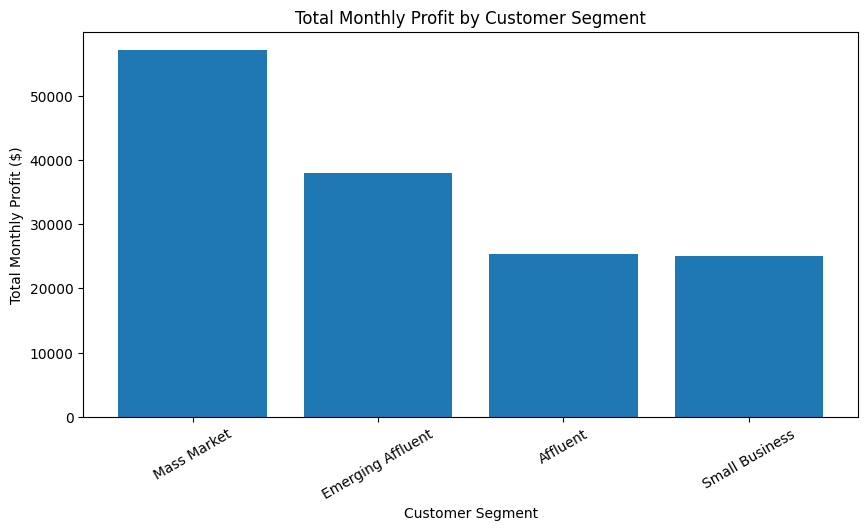

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(segment_summary["customer_segment"], segment_summary["total_profit"])
plt.title("Total Monthly Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Monthly Profit ($)")
plt.xticks(rotation=30)
plt.show()

## 5. Churn Risk Analysis

This section reviews churn risk by risk band and identifies patterns among customers most likely to leave.

In [11]:
churn_risk_summary = (
    banking
    .groupby("churn_risk_band")
    .agg(
        customers=("customer_id", "count"),
        avg_balance=("total_balance", "mean"),
        avg_profit=("monthly_profit", "mean"),
        avg_product_count=("product_count", "mean"),
        avg_support_calls=("support_calls_90d", "mean"),
        avg_digital_logins=("digital_logins_90d", "mean"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

churn_risk_summary

,churn_risk_band,customers,avg_balance,avg_profit,avg_product_count,avg_support_calls,avg_digital_logins,churn_rate
0,High Risk,97,"7,335.40",-41.34,2.53,4.54,22.00,0.36
1,Low Risk,3870,"15,727.35",40.66,4.09,1.23,21.98,0.06
2,Medium Risk,1033,"12,132.16",-7.51,3.31,3.03,22.03,0.22


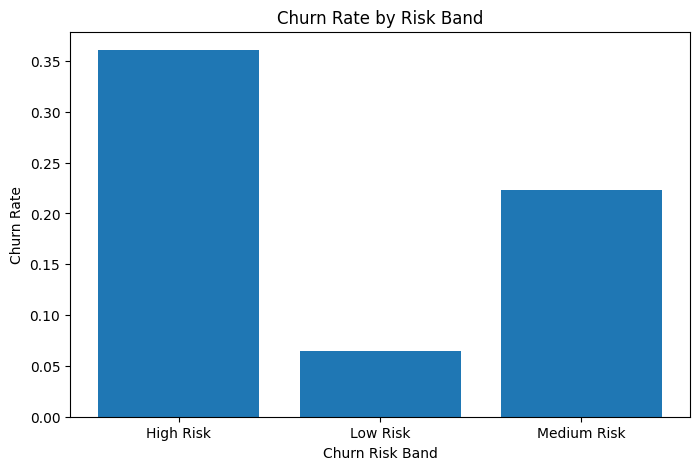

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(churn_risk_summary["churn_risk_band"], churn_risk_summary["churn_rate"])
plt.title("Churn Rate by Risk Band")
plt.xlabel("Churn Risk Band")
plt.ylabel("Churn Rate")
plt.show()

## 6. Product Usage and Churn

Customers with more products are usually more deeply connected to the bank. This section compares product count with churn behavior.

In [13]:
product_churn_summary = (
    banking
    .groupby("product_count")
    .agg(
        customers=("customer_id", "count"),
        avg_balance=("total_balance", "mean"),
        avg_profit=("monthly_profit", "mean"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

product_churn_summary

,product_count,customers,avg_balance,avg_profit,churn_rate
0,1,10,97.61,-38.55,0.50
1,2,248,"5,743.32",-28.79,0.21
2,3,1472,"12,752.36",-16.21,0.14
3,4,2046,"15,539.87",26.79,0.10
4,5,991,"17,843.03",87.05,0.04
5,6,215,"19,551.96",150.94,0.03
6,7,18,"12,858.09",190.51,0.00


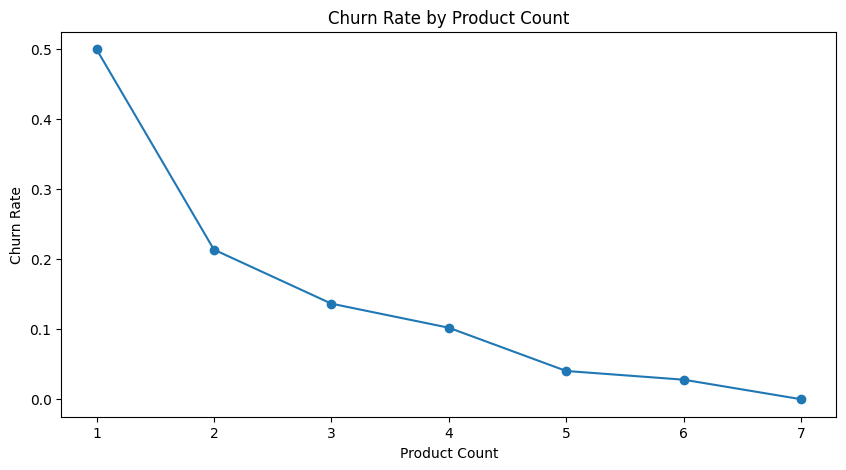

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(product_churn_summary["product_count"], product_churn_summary["churn_rate"], marker="o")
plt.title("Churn Rate by Product Count")
plt.xlabel("Product Count")
plt.ylabel("Churn Rate")
plt.show()

## 7. Digital Engagement Analysis

Digital banking activity is an important signal for customer engagement. This section compares digital logins, support calls, and churn.

In [15]:
banking["digital_engagement_band"] = pd.cut(
    banking["digital_logins_90d"],
    bins=[-1, 5, 15, 30, 100],
    labels=["Very Low", "Low", "Medium", "High"]
)

digital_summary = (
    banking
    .groupby("digital_engagement_band", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_profit=("monthly_profit", "mean"),
        avg_product_count=("product_count", "mean"),
        avg_support_calls=("support_calls_90d", "mean"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

digital_summary

,digital_engagement_band,customers,avg_profit,avg_product_count,avg_support_calls,churn_rate
0,Low,360,29.96,3.92,1.63,0.09
1,Medium,4449,29.21,3.90,1.66,0.10
2,High,191,25.29,3.80,1.85,0.13


In [16]:
banking["digital_engagement_band"] = pd.cut(
    banking["digital_logins_90d"],
    bins=[-1, 5, 15, 30, 100],
    labels=["Very Low", "Low", "Medium", "High"]
)

digital_summary = (
    banking
    .groupby("digital_engagement_band", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_profit=("monthly_profit", "mean"),
        avg_product_count=("product_count", "mean"),
        avg_support_calls=("support_calls_90d", "mean"),
        churn_rate=("churned", "mean")
    )
    .reset_index()
)

digital_summary

,digital_engagement_band,customers,avg_profit,avg_product_count,avg_support_calls,churn_rate
0,Low,360,29.96,3.92,1.63,0.09
1,Medium,4449,29.21,3.90,1.66,0.10
2,High,191,25.29,3.80,1.85,0.13


## 8. High-Value At-Risk Customers

This section identifies customers who are profitable or have meaningful balances but also show higher churn risk. These customers may be good candidates for retention campaigns.

In [17]:
high_value_at_risk = (
    banking[
        (banking["churn_risk_band"] == "High Risk") &
        ((banking["monthly_profit"] > banking["monthly_profit"].median()) |
         (banking["total_balance"] > banking["total_balance"].median()))
    ]
    .sort_values(["monthly_profit", "total_balance"], ascending=False)
)

high_value_at_risk[
    [
        "customer_id", "state", "customer_segment", "income_band",
        "total_balance", "product_count", "monthly_profit",
        "support_calls_90d", "digital_logins_90d",
        "churn_probability", "churn_risk_band"
    ]
].head(20)

,customer_id,state,customer_segment,income_band,total_balance,product_count,monthly_profit,support_calls_90d,digital_logins_90d,churn_probability,churn_risk_band
925,CUST000926,GA,Affluent,40K-75K,0.00,2,37.00,0,30,0.35,High Risk
1917,CUST001918,OR,Emerging Affluent,75K-125K,0.00,2,34.46,1,24,0.35,High Risk
2866,CUST002867,MI,Mass Market,75K-125K,0.00,2,21.83,5,26,0.48,High Risk
2940,CUST002941,PA,Emerging Affluent,75K-125K,"30,542.69",4,-0.25,8,22,0.37,High Risk
2128,CUST002129,FL,Mass Market,125K-200K,"38,037.67",2,-6.98,0,27,0.36,High Risk
3498,CUST003499,TN,Affluent,75K-125K,"15,566.10",2,-10.22,0,18,0.36,High Risk
2862,CUST002863,MA,Mass Market,75K-125K,"25,162.94",2,-13.42,0,23,0.36,High Risk
4316,CUST004317,NY,Affluent,75K-125K,"12,282.19",3,-17.81,4,24,0.37,High Risk
4330,CUST004331,CO,Mass Market,125K-200K,"32,262.08",3,-27.89,4,19,0.37,High Risk
2899,CUST002900,NJ,Mass Market,125K-200K,"21,667.25",4,-32.37,7,23,0.37,High Risk


## 9. Basic Machine Learning Model for Churn Prediction

A basic machine learning model is used to predict whether a customer is likely to churn. The goal is not to build a perfect model, but to demonstrate how customer attributes, balances, engagement, and product usage can be used for churn prediction.

In [18]:
features = [
    "state",
    "age_group",
    "income_band",
    "customer_segment",
    "credit_score_band",
    "tenure_band",
    "total_balance",
    "product_count",
    "digital_logins_90d",
    "branch_visits_90d",
    "support_calls_90d",
    "monthly_deposits",
    "monthly_card_spend",
    "monthly_revenue",
    "servicing_cost",
    "monthly_profit"
]

target = "churned"

X = banking[features]
y = banking[target]

categorical_features = [
    "state",
    "age_group",
    "income_band",
    "customer_segment",
    "credit_score_band",
    "tenure_band"
]

numeric_features = [
    "total_balance",
    "product_count",
    "digital_logins_90d",
    "branch_visits_90d",
    "support_calls_90d",
    "monthly_deposits",
    "monthly_card_spend",
    "monthly_revenue",
    "servicing_cost",
    "monthly_profit"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=150,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", round(accuracy, 4))
print()
print(classification_report(y_test, predictions))

Model Accuracy: 0.8976

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1122
           1       0.00      0.00      0.00       128

    accuracy                           0.90      1250
   macro avg       0.45      0.50      0.47      1250
weighted avg       0.81      0.90      0.85      1250



c:\Users\Bereket\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bereket\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Bereket\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [19]:
cm = confusion_matrix(y_test, predictions)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Churned", "Actual Churned"],
    columns=["Predicted Not Churned", "Predicted Churned"]
)

cm_df

,Predicted Not Churned,Predicted Churned
Actual Not Churned,1122,0
Actual Churned,128,0


## 10. Feature Importance

Feature importance helps explain which factors were most useful to the model when predicting churn.

In [20]:
classifier = model.named_steps["classifier"]
preprocessor_fitted = model.named_steps["preprocessor"]

encoded_cat_features = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = list(encoded_cat_features) + numeric_features

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": classifier.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
54,monthly_profit,0.10
52,monthly_revenue,0.09
50,monthly_deposits,0.08
45,total_balance,0.08
53,servicing_cost,0.06
47,digital_logins_90d,0.06
51,monthly_card_spend,0.04
49,support_calls_90d,0.04
46,product_count,0.03
48,branch_visits_90d,0.03


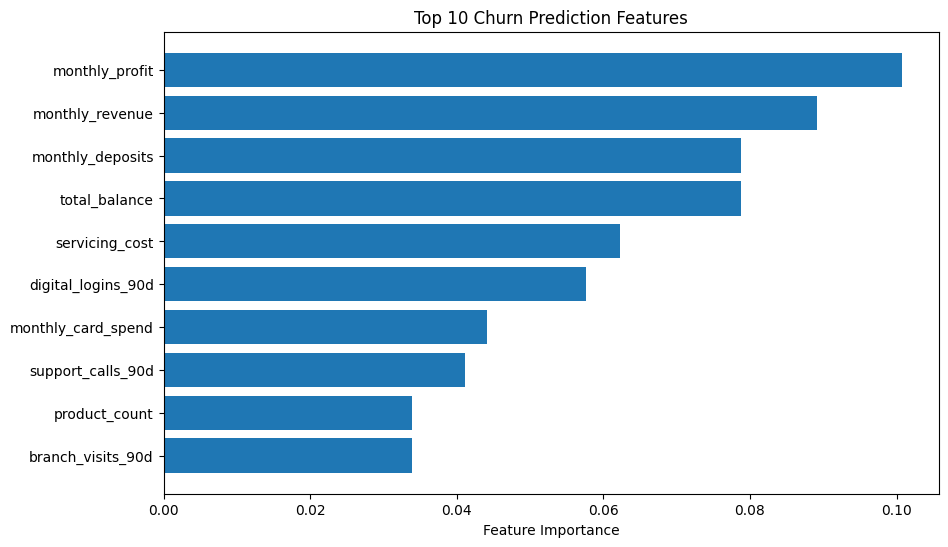

In [21]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 10 Churn Prediction Features")
plt.xlabel("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## 11. Final Business Insights

In [22]:
most_profitable_segment = segment_summary.iloc[0]["customer_segment"]
highest_churn_risk_band = churn_risk_summary.sort_values("churn_rate", ascending=False).iloc[0]["churn_risk_band"]
highest_churn_product_count = product_churn_summary.sort_values("churn_rate", ascending=False).iloc[0]["product_count"]
lowest_digital_engagement_churn = digital_summary.sort_values("churn_rate", ascending=False).iloc[0]["digital_engagement_band"]

print("Final Business Insights")
print("------------------------")
print(f"Total customers analyzed: {total_customers:,}")
print(f"Total customer balances: ${total_balance:,.2f}")
print(f"Total monthly revenue: ${total_monthly_revenue:,.2f}")
print(f"Total monthly profit: ${total_monthly_profit:,.2f}")
print(f"Overall churn rate: {churn_rate:.2%}")
print(f"High churn risk customers: {high_churn_risk_customers:,}")
print(f"Most profitable customer segment: {most_profitable_segment}")
print(f"Risk band with highest churn rate: {highest_churn_risk_band}")
print(f"Product count group with highest churn rate: {highest_churn_product_count}")
print(f"Digital engagement group with highest churn rate: {lowest_digital_engagement_churn}")
print(f"Churn model accuracy: {accuracy:.2%}")

Final Business Insights
------------------------
Total customers analyzed: 5,000
Total customer balances: $74,108,921.51
Total monthly revenue: $325,509.32
Total monthly profit: $145,575.32
Overall churn rate: 10.28%
High churn risk customers: 97
Most profitable customer segment: Mass Market
Risk band with highest churn rate: High Risk
Product count group with highest churn rate: 1.0
Digital engagement group with highest churn rate: High
Churn model accuracy: 89.76%


## Conclusion

This project demonstrates how banking customer data can be used to analyze churn, profitability, product usage, and retention opportunities.

The analysis shows that churn risk is connected to customer engagement, product depth, support activity, profitability, balance levels, and tenure. A basic machine learning model was also used to predict churn and identify important churn-related features.

This project demonstrates practical skills for banking analytics, financial analysis, business analysis, operations analysis, FinTech analytics, and junior data analyst roles.